## Data Processing

In [1]:
from pathlib import Path
from os.path import splitext
import numpy as np
import pandas as pd

PROCESSING_DIR = Path(".")
ABLATION_DIR = PROCESSING_DIR / "results/debloated"
BASELINE_DIR = PROCESSING_DIR / "results/baseline"

PRICE_PER_MS_PER_MB_PER_100K_REQ = 0.00000162109


def get_estimated_cost(mem, time):
    # mem in MB, time in ms
    if mem < 128:
        mem = 128
    return mem * PRICE_PER_MS_PER_MB_PER_100K_REQ * time


# collect varying k result and generate into a pandas dataframe
def collect_data(app_name: str):
    ks = [1, 5, 10, 15, 20, 30, 40, 50]

    key = ["e2e_latency", "mem_used", "billed_duration", "import_time"]

    for k in ks:
        if not (ABLATION_DIR / f"{app_name}_k{k}_cost.csv").exists():
            raise FileNotFoundError(f"File {ABLATION_DIR}/{app_name}_k{k}_cost.csv does not exist.")

    debloated_data = {
        name: np.array([pd.read_csv(f"{ABLATION_DIR}/{app_name}_k{k}_cost.csv")[name].mean() for k in ks])
        for name in key
    }

    debloated_data["billed_duration"] /= 1000

    debloated_data["cost"] = np.array([
        get_estimated_cost(m, t)
        for m, t in zip(debloated_data["mem_used"], debloated_data["billed_duration"])
    ])

    baseline_file = pd.read_csv(BASELINE_DIR / f"{app_name}.csv")
    baseline_file["billed_duration"] /= 1000
    baseline_data = {
        "mem_used": baseline_file["mem_used"].mean(),
        "e2e_latency": baseline_file["e2e_latency"].mean(),
        "billed_duration": baseline_file["billed_duration"].mean(),
        "import_time": baseline_file["import_time"].mean(),
    }
    baseline_data["cost"] = get_estimated_cost(
        baseline_data["mem_used"].mean(), baseline_data["billed_duration"].mean()
    )

    return pd.DataFrame({"k": list(ks), **debloated_data}), baseline_data

## Plotting

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.rc("font", size=18)


def plot(app_name: str):
    debloated_data, baseline = collect_data(app_name)

    plt.clf()
    plt.figure(figsize=(12, 3))

    maxval = 0
    minval = 0

    MARKERS = ["X", "o", "s"]

    with sns.color_palette("dark"):
        for i, (aspect, label) in enumerate([
            ("mem_used", "Memory"),
            ("e2e_latency", "Latency"),
            ("cost", "Cost"),
        ]):
            improves = (baseline[aspect] - debloated_data[aspect]) * 100 / baseline[aspect]
            maxval = max(maxval, max(improves))
            minval = min(minval, min(improves))
            plt.plot(debloated_data["k"], improves, marker=MARKERS[i], label=label, linewidth=1, markersize=10, linestyle="--", dashes=(5, 5))

    plt.xticks(list(filter(lambda x: x != 2, debloated_data["k"])))
    plt.xlabel("Number of modules to debloat (K)")
    plt.ylabel("Improvment/%")
    plt.ylim(minval - 5, maxval + 20)
    plt.grid()
    legend = plt.legend(ncol=3, edgecolor="k", facecolor="white")
    legend.get_frame().set_alpha(None)
    legend.get_frame().set_boxstyle("square, pad=0")
    plt.title(f"Application: {app_name}")
    plt.savefig(PROCESSING_DIR / f"figures/varying-k-{app_name}.pdf", bbox_inches="tight")

    k  e2e_latency   mem_used  billed_duration  import_time      cost
0   1     0.599703  53.000000         0.341204     0.180456  0.000071
1   5     0.584877  50.030612         0.336112     0.169348  0.000070
2  10     0.577612  50.000000         0.325378     0.160455  0.000068
3  15     0.547641  48.989691         0.299443     0.135013  0.000062
4  20     0.534406  48.010309         0.278918     0.121543  0.000058
5  30     0.566435  48.000000         0.306216     0.136327  0.000064
6  40     0.592726  47.010417         0.320469     0.133355  0.000066
7  50     0.566265  47.000000         0.299443     0.129928  0.000062
{'mem_used': np.float64(52.99), 'e2e_latency': np.float64(0.65995361328125), 'billed_duration': np.float64(0.38378), 'import_time': np.float64(0.21139755010604858), 'cost': np.float64(7.96341657856e-05)}


<Figure size 640x480 with 0 Axes>

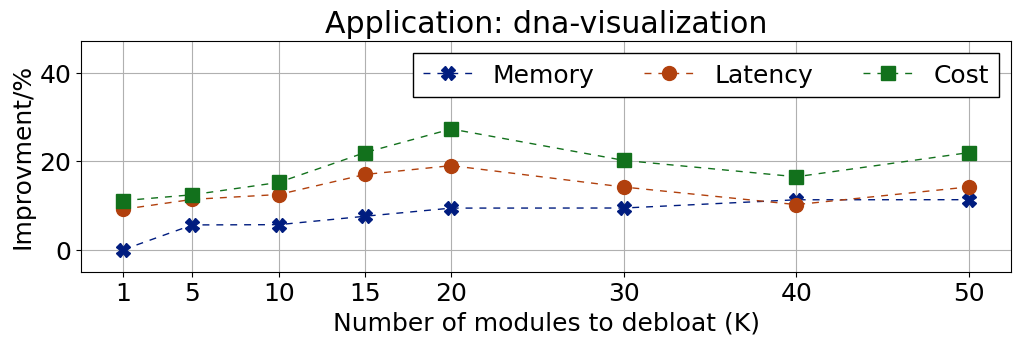

In [4]:
plot("dna-visualization")

<Figure size 640x480 with 0 Axes>

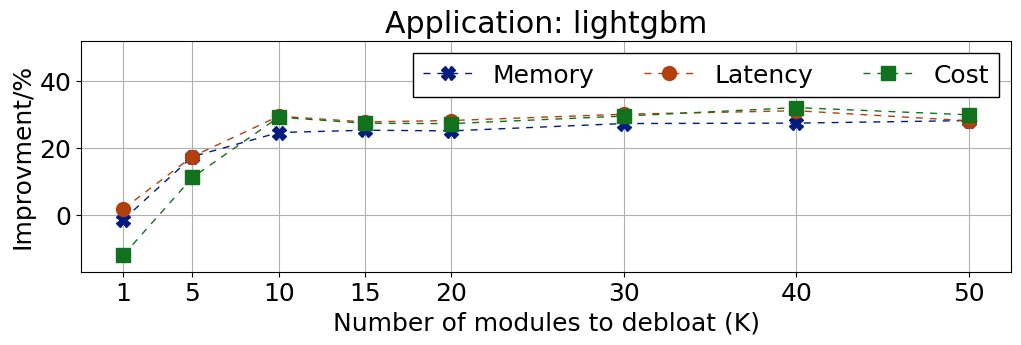

In [60]:
plot("lightgbm")

<Figure size 640x480 with 0 Axes>

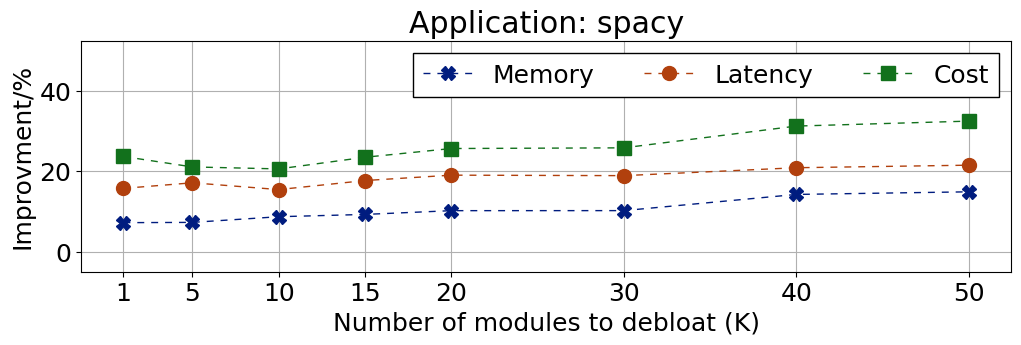

In [61]:
plot("spacy")